# Electronic Structure Analysis of Materials

By Adriana J. Ladera

Center for Computational Science and Engineering, Massachusetts Institute of Technology

This is a tool to help analyze VASP calculations. It gets the total force on an atom, grabs info for VBM and CBM orbital partial charge calculations, and plots the electronic structure computed from VASP calculations of structures, specifically band structure, the density of states, and the Brillouin zones. All final figures are saved to a directory created during runtime called 'figures-and-data'.

## Import libraries

In [1]:
import os
path = "/Users/adrianaladera/Desktop/MIT/RESEARCH/Github_repos/SolidState-dont-Evaporate/"
os.chdir(path)
        
from analyzer.electronicstructure import ElectronicStructurePlotter, EffectiveMass, BandAlignment
from utils import utils
from utils.packages import *
METALS = ['Ag', 'Au', 'Hg', 'Cu']
CHALCS = ['Te', 'Se', "S"]

## Getting the data from the .vasprunxml files and setting some parameters

In [2]:
# root = "/Users/adrianaladera/Desktop/MIT/RESEARCH/VASP_calculations/sugar_mochas/ligs_to_ISIF2/glu_v3/"
root = "/Users/adrianaladera/Desktop/MIT/research/VASP_calculations/fluorescent_1D/unrefined_relaxing/3meth_1D2D_paper/"
# /4methoxy/"
band_xlim = None # CHANGE ME
ylim = [-2.5,5.0]
xlim = [-1,10]
dos_xlim = [-1,1]
line_width, font_size, marker = 3, 19, 22
savefig = False
rel_type = ""
esp = ElectronicStructurePlotter(root, savefig=True)

## Band Structure
Groups elements by color for the finalized band structure

- Red bands are inorganic interactions, black bands are organic interactions, and colors are interpolated
- **Valence band maxima, VBM (green)** $\rightarrow$ the valence band maxima from which electrons can jump
- **Conduction band minima, CBM (blue)** $\rightarrow$ the conduction band minima to which electrons from the valence band can traverse to
- **band gap** $\rightarrow$ the gap in energy, measured from the VBM to the CBM. The band gap can be either indirect, in which the VBM(s) and CBM(s) are not aligned at the same k-point, or direct, in which they are. When an electron traverses the band gap, a photon is emitted, though with indrect band gap materials this usually requires a change in momentum and is often aided by phonons. This means that direct band gap materials are also more efficient at emitting light.

In [5]:
# bandz will make her dance 
# bandrun = BSVasprun(f"{root}/{rel_type}/band/vasprun.xml", parse_projected_eigen=True, occu_tol=1e-8)
# bs = bandrun.get_band_structure(f"{root}/{rel_type}/band/KPOINTS")
# Usage — first call is slow, all subsequent calls are instant
bs = utils.load_band_structure_cached(
    f"{root}/{rel_type}/band/vasprun.xml",
    f"{root}/{rel_type}/band/KPOINTS",
    parse_projected_eigen=True,
    occu_tol=1e-8
)
yourmom = esp.get_band_data(bs)
print(yourmom)
# bsp = BSPlotter(bs)
# band_labels, vbm, cbm = esp.color_bs_plotter(bsp, smooth=True, vbm_marker=True, cbm_marker=True, marker_size=5, xlim=None, ylim=ylim)

      vbm     cbm   eFermi  bandgap                                 transition
0  1.0831  3.0208  1.09962   1.9377  (0.000,-0.500,0.500)-(0.000,-0.490,0.490)


## Density of States

[some blurb about DOS here] Like the band diagram, DOS also shows the band gap of materials.

Based on the DOSPlotter() module from Pymatgen, except much prettier YEEHAW

Takes in a DOSPlotter object and produces a matplotlib plot that plots the density of states by element in the material. The final figure is saved to a directory created during runtime called 'figures-and-data'.

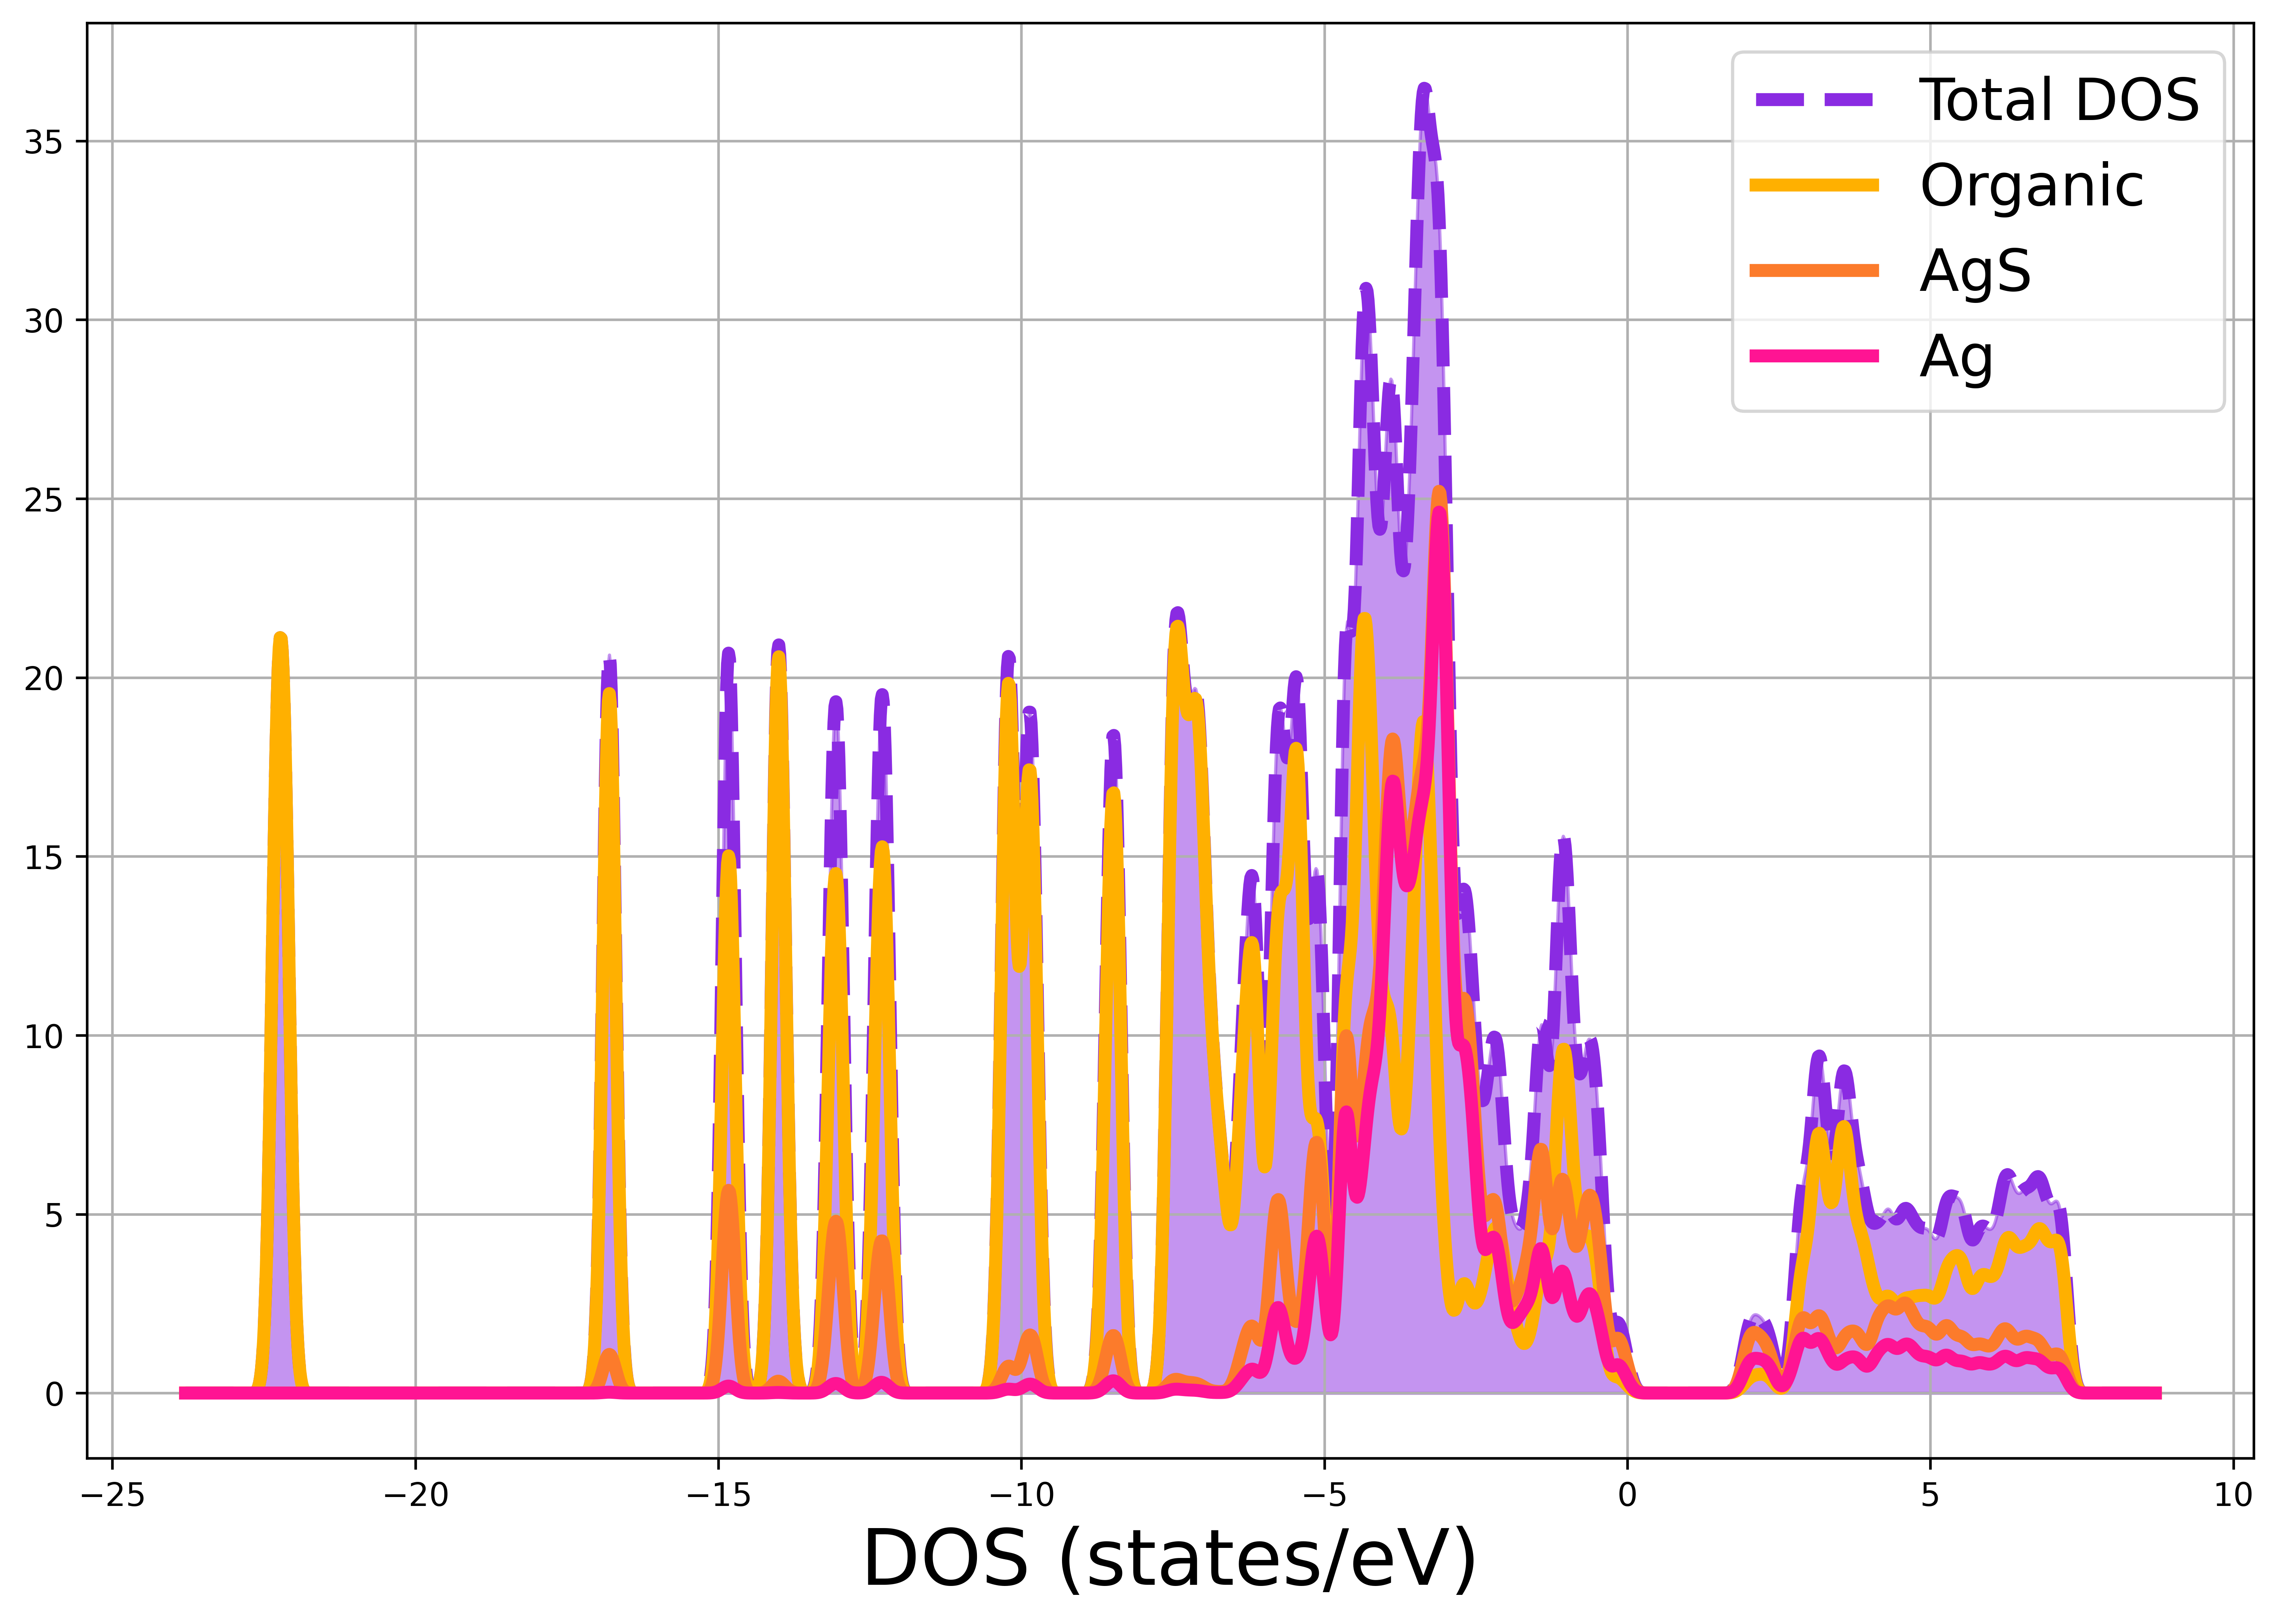

In [3]:
dosrun = Vasprun(f"{root}/{rel_type}/dos/vasprun.xml", parse_dos=True)
dos = dosrun.complete_dos
dosplot = DosPlotter(sigma=0.1)
dosplot.add_dos_dict(dos.get_element_dos())
esp.sexy_dosplot(dosplot)

## Getting band mixing metric between inorganic and organic DOS
This is a metric based on projected density of states of the mixing of the bands between the two sub lattices to quantify the increase in mixing for this one structure versus the others. We define “mixing” as the ratio: PDOS(Ag+S)/PDOS(organic) where the numerator is the average of Ag/S component of the PDOS integrated within 1 eV of the VBM or CBM and the denominator is the average of all atoms on the organic sub lattice integrated over 1 eV of the VBM/CBM. If you get something close to 0, that is an organic band and if you see the number goes to infinity (or its inverse goes to zero), you have an inorganic band

For each energy point in that 1 eV window, get the PDOS projected onto Ag and S atoms. Then, sum the PDOS contributions from all Ag and S atoms, and then average if needed. Finally, integrate that total PDOS across the energy window — e.g., using trapezoidal rule over the energy grid (`np.trapz` on PDOS vs energy).

* Note from Tess: Number of outer shell electrons something I can get from an output VASP file? I found that if you grep ZVAL from the POTCAR it gives you the valence electrons per atomic species, and I'm guessing you just multiply that by however many atoms appear in the MOCha (like if ZVAL = 11 for Ag, ZVAL = 6 for S, and there are 4 Ag and 4 S atoms then the total valence electrons to normalize the number of states by is something like 44 + 24). The inner electrons are folded into the pseudopotential, and the outer valence electrons are the ones that are important.

Let 

$$
    PDOS_{inorganic}(E) = \sum_{N_{inorganic}}PDOS(E)
$$
$$
    PDOS_{organic}(E) = \sum_{N_{organic}}PDOS(E)
$$

Then,

$$
        mixing~metric = \frac{\int_{E_1}^{E_2}PDOS_{inorganic}(E)dE}{\int_{E_1}^{E_2}PDOS_{organic}(E)dE}
$$

where 

VBM:$|E_1, E_2| = |E_{VBM}-1, E_{VBM}|$

CBM:$|E_1, E_2| = |E_{CBM}, E_{CBM}+1|$

In [ ]:
import numpy as np
from pymatgen.electronic_structure.core import Spin

# numpy 2.0 renamed trapz -> trapezoid; fall back for older installs
_trapz = getattr(np, "trapezoid", getattr(np, "trapz"))

INORGANIC = {"Ag", "S"}  # the 1D AgS wire


def _summed_density(edos, elements):
    """Sum spin channels and the requested elements into one density array."""
    total = None
    for el, d in edos.items():
        if el.symbol not in elements:
            continue
        dens = sum(d.densities.values())  # Spin.up (+ Spin.down if present)
        total = dens if total is None else total + dens
    if total is None:
        raise ValueError(f"No DOS found for {elements}")
    return total


def _integrate_window(energies, density, e_lo, e_hi):
    """Trapezoidal integral over [e_lo, e_hi] with interpolated endpoints,
    so the window width is identical across structures regardless of grid."""
    d_lo = np.interp(e_lo, energies, density)
    d_hi = np.interp(e_hi, energies, density)
    mask = (energies > e_lo) & (energies < e_hi)
    e = np.concatenate(([e_lo], energies[mask], [e_hi]))
    d = np.concatenate(([d_lo], density[mask], [d_hi]))
    return _trapz(d, e)


def _norm_factors(mode, inorganic, organic, structure, potcar):
    if mode is None:
        return 1.0, 1.0
    counts = structure.composition.get_el_amt_dict()
    if mode == "atoms":
        n_in = sum(v for k, v in counts.items() if k in inorganic)
        n_or = sum(v for k, v in counts.items() if k in organic)
        return n_in, n_or
    if mode == "valence":
        # robust ZVAL accessor across pymatgen versions
        def zval(p):
            for attr in ("zval", "ZVAL"):
                if hasattr(p, attr):
                    return float(getattr(p, attr))
            return float(p.keywords["ZVAL"])
        z = {p.element: zval(p) for p in potcar}
        n_in = sum(counts[k] * z[k] for k in counts if k in inorganic)
        n_or = sum(counts[k] * z[k] for k in counts if k in organic)
        return n_in, n_or
    raise ValueError(f"unknown normalize mode {mode!r}")


def mixing_metric(
    complete_dos,
    window=1.0,
    vbm=None,
    cbm=None,
    inorganic=INORGANIC,
    normalize=None,        # None (recommended) | "atoms" | "valence"
    structure=None,        # required for normalize != None
    potcar=None,           # required for normalize == "valence"
):
    """Inorganic-vs-organic PDOS mixing metric, computed separately at the
    valence and conduction edges.

    Returns {"valence": {...}, "conduction": {...}} with the integrated
    inorganic/organic PDOS, their ratio, and the inorganic fraction.
    """
    edos = complete_dos.get_element_dos()          # {Element: Dos}
    energies = np.asarray(complete_dos.energies)   # absolute eV, matches get_cbm_vbm

    if vbm is None or cbm is None:
        cbm_auto, vbm_auto = complete_dos.get_cbm_vbm()  # note: (cbm, vbm) order
        vbm = vbm_auto if vbm is None else vbm
        cbm = cbm_auto if cbm is None else cbm

    organic = {el.symbol for el in edos} - set(inorganic)

    d_in = _summed_density(edos, inorganic)
    d_or = _summed_density(edos, organic)

    n_in, n_or = _norm_factors(normalize, inorganic, organic, structure, potcar)
    d_in, d_or = d_in / n_in, d_or / n_or

    windows = {
        "valence":    (vbm - window, vbm),
        "conduction": (cbm, cbm + window),
    }
    out = {}
    for name, (e_lo, e_hi) in windows.items():
        I_in = _integrate_window(energies, d_in, e_lo, e_hi)
        I_or = _integrate_window(energies, d_or, e_lo, e_hi)
        out[name] = {
            "E_window": (float(e_lo), float(e_hi)),
            "I_inorganic": float(I_in),
            "I_organic": float(I_or),
            "ratio_in_over_or": float(I_in / I_or) if I_or else np.inf,
            "frac_inorganic": float(I_in / (I_in + I_or)) if (I_in + I_or) else np.nan,
        }
    return out

## Band Alignment

In [4]:
from pymatgen.io.vasp.outputs import BSVasprun
from pymatgen.electronic_structure.core import Spin
import matplotlib.pyplot as plt
from functools import cached_property

# 3. Instantiate and plot

class BA:
    def __init__(self, path, matches, bs, projection_tol, savefig):
        self.path = path
        self.savefig = savefig
        self.matches = matches
        self.tolerance = projection_tol
        self.bs = bs

    def _get_max_projections(self, proj_data, band_gap, is_vbm=True):
        '''
        Vectorized version that gets the max projection value
        of all k-points in a given band.

        proj_data: list[list[dict[str, float]]]
            Outer list: bands
            Inner list: k-points
            Dict: {element: projection value}

        Returns:
            dict[element] = (max_value, kpoint_index, band_index)
        '''

        # decrease from band_gap if is_vbm, else increase from band_gap
        band_range = range(band_gap, -1, -1) if is_vbm else range(band_gap, len(proj_data))
        # get element keys from first valid band/kpoint
        elements = list(proj_data[band_range[0]][0].keys())
        
        # build array: shape (n_bands_in_range, n_kpoints, n_elements)
        arr = np.array([
            [[kp.get(el, 0.0) for el in elements] for kp in proj_data[b]]
            for b in band_range
        ])  # shape: (bands, kpoints, elements)

        max_proj = {}
        for e_idx, element in enumerate(elements):
            el_vals = arr[:, :, e_idx]  # shape: (bands, kpoints)
            mask = el_vals > self.tolerance
            if not np.any(mask):
                continue
            # find first occurrence in band_range order
            band_idx, k_idx = np.argwhere(mask)[0]  # first hit
            actual_band = list(band_range)[band_idx]
            max_proj[element] = (el_vals[band_idx, k_idx], k_idx, actual_band)

        return max_proj
    
    def _find_band_edge(self, matches):
        """Vectorized VBM/CBM index detection from matches array."""
        # matches shape: (n_kpoints, n_bands, 2) — col 1 is the binary occupancy
        occ = np.array([[float(b[1]) for b in kp] for kp in matches])  # (kpts, bands)
        
        # Find columns where occ transitions 1→0 along band axis
        transitions = (occ[:, :-1] != 0) & (occ[:, 1:] == 0)  # (kpts, bands-1)
        hits = np.argwhere(transitions)
        
        if len(hits) == 0:
            raise ValueError("No VBM/CBM transition found in matches")
        
        vbm = int(hits[0, 1])      # band index of VBM
        cbm = int(hits[0, 1]) + 1  # band index of CBM
        return vbm, cbm
    
    def _get_band_proj_per_atom(self, matches, proj):
        '''
        Gets the indices of the VBM and CBM, then for both the 
        VBM and CBM, gets the projections for each atom onto the 
        band.

        Args:
            matches: (3D array) dims: n_kpoints x n_bands x len([eigenvalue, binary])
            proj: (dict) BSVasprun.get_band_structure().get_projection_on_elements()

        Returns:
            vbm_data: (dict) {(str) atomic species: (float) first corresponding projection
            > 0.1 decreasing from VBM value}
            cbm_data: (dict) {(str) atomic species: (float) first corresponding projection
            > 0.1 increasing from CBM value}

        '''
        vbm, cbm = self._find_band_edge(matches)

        vbm_data = self._get_max_projections(proj[Spin.up], band_gap=vbm, is_vbm=True)
        cbm_data = self._get_max_projections(proj[Spin.up], band_gap=cbm, is_vbm=False)

        for unwanted in [0, 'H']:
            vbm_data.pop(unwanted, None)
            cbm_data.pop(unwanted, None)

        return vbm_data, cbm_data

    def _get_band_alignment(self, vbm_data, cbm_data, bs):
        ''' 
        Gets the max projection in the VBM and min projection 
        in the CBM of all the atomic species, for both the 
        inorganic and organic species.

        Args:
            vbm_data: (dict) atomic species and their corresponding 
            projections from the VBM
            cbm_data: (dict) atomic species and their corresponding 
            projections from the CBM
            bs: (pymatgen.io.vasp.outputs.BSVasprun.get_band_structure())

        Returns: 
            tuple(
                vbm_final: (dict) {(str) "Inorganic": (float) max value of 
                projections, (str) "Organic": (float) max value of projections}
                cbm_final: (dict) {(str) "Inorganic": (float) min value of 
                projections, (str) "Organic": (float) min value of projections}
            )

        '''
        bands = bs.bands[Spin.up]  # shape: (n_bands, n_kpoints) — pull once
        common_atoms = set(vbm_data) & set(cbm_data)
        vbm_inorg, cbm_inorg, vbm_org, cbm_org = [], [], [], []

        for atom in common_atoms:
            # batch lookups to not index just one atom at a time
            _, vbm_k, vbm_b = vbm_data[atom]
            _, cbm_k, cbm_b = cbm_data[atom]
            
            vbm_val = bands[vbm_b, vbm_k]  # direct numpy indexing, no loop
            cbm_val = bands[cbm_b, cbm_k]

            # sort atoms by inorganic or organic species
            target_inorg = atom in METALS or atom in CHALCS
            (vbm_inorg if target_inorg else vbm_org).append(vbm_val)
            (cbm_inorg if target_inorg else cbm_org).append(cbm_val)

        # get min CBM / max VBM for all inorganic / organic species
        vbm_final = {
            k: v for k, v in [
                ("Inorganic", max(vbm_inorg) if vbm_inorg else None),
                ("Organic",   max(vbm_org)   if vbm_org   else None),
            ] if v is not None
        }
        cbm_final = {
            k: v for k, v in [
                ("Inorganic", min(cbm_inorg) if cbm_inorg else None),
                ("Organic",   min(cbm_org)   if cbm_org   else None),
            ] if v is not None
        }

        return vbm_final, cbm_final

    @cached_property
    def _proj(self):
        ''' cache it on the instance so it doesn't recompute every call '''
        return self.bs.get_projection_on_elements()
    
    def get_max_cbm_min_vbm(self):
        ''' 
        Plots the band alignment for the inorganic and organic bands.

        Args:
            vbm_gaps: (dict) the VBM values for the inorganic and organic bands
            cbm_gaps: (dict) the CBM values for the inorganic and organic bands
        '''
        matches = self.matches
        bs = self.bs

        # proj = bs.get_projection_on_elements()
        vbm_shit, cbm_shit = self._get_band_proj_per_atom(matches, self._proj)
        vbm_gaps, cbm_gaps = self._get_band_alignment(vbm_shit, cbm_shit, bs)
 
        vbm_o = vbm_gaps["Organic"]
        vbm_i = vbm_gaps["Inorganic"]
        cbm_o = cbm_gaps["Organic"]
        cbm_i = cbm_gaps["Inorganic"]
        max_cbm = max(cbm_i, cbm_o)
        min_vbm = min(vbm_i, vbm_o)
        
        return min_vbm, max_cbm

## Plot band structure and band alignment in the same plot

In [5]:
from pymatgen.electronic_structure.core import Spin
import matplotlib.pyplot as plt

class ESP:
    def __init__(self, path, savefig=False, tag=''):
        if not os.path.exists(f"{path}/figures-and-data"):
            os.mkdir(f"{path}/figures-and-data")

        self.path = path
        self.savefig = savefig
        self.tag = tag

    def _projections_to_array(self, projections):
        """Converts projection data to numpy array.
        
        projections: output of BandStructure.get_projection_on_elements()
        output: np.array of size [n_spin, n_bands, n_panes * distances, n_elements]
        """
        array = []
        for spin in projections.keys():
            spin_array = []
            for band in projections[spin]:
                band_array = []
                for d in band:
                    band_array.append(np.array(list(d.values())))
                spin_array.append(np.stack(band_array, axis=0))
            array.append(np.stack(spin_array, axis=0))
        return np.stack(array, axis=0)

    def _get_element_projection_keys(self, projections):
        for spin in projections.keys():
            for band in projections[spin]:
                for d in band:
                    return d.keys()
                
    def get_band_data(self, bs):
        '''Writes BSVasprun data to csv file'''
        path = self.path
        savedata = self.savefig
        
        data = bs.as_dict()

        vbm = data["vbm"]["energy"]
        cbm = data["cbm"]["energy"]
        efermi = data["efermi"]
        bandgap = data["band_gap"]["energy"]
        transition = data["band_gap"]["transition"]

        df = pd.DataFrame({"vbm": vbm, "cbm":cbm, "eFermi":efermi, "bandgap": bandgap, "transition":transition},index=[0])

        if savedata:
            if not os.path.exists(f"{path}/figures-and-data"):
                os.mkdir(f"{path}/figures-and-data")
            df.to_csv(f"{path}/figures-and-data/estruct_energy_data{self.tag}.csv")
        
        return df

    def color_bs_ba_plotter(
    self,
    bandz,
    band_alignment,
    dos,
    band_xlim,
    zero_to_efermi=True,
    # selected_indices=None,
    energy_lim=None,
    dos_xlim=None,
    dos_xticks=None,
    smooth=False,
    vbm_marker=True,
    cbm_marker=True,
    smooth_tol=0,
    smooth_k=3,
    smooth_np=100,
    bs_labels=None,
    marker_size=None,
    legend=False
    ):
        """
        By Tess Smidt and Adriana Ladera. 
        Dos Plotter by Adriana Ladera.
        Get a matplotlib object for the bandstructures plot.
        Multiple bandstructure objs are plotted together if they have the
        same high symm path.
        Args:
            zero_to_efermi: Automatically subtract off the Fermi energy from
                the eigenvalues and plot (E-Ef).
            ylim: Specify the y-axis (energy) limits; by default None let
                the code choose. It is vbm-4 and cbm+4 if insulator
                efermi-10 and efermi+10 if metal
            smooth (bool or list(bools)): interpolates the bands by a spline cubic.
                A single bool values means to interpolate all the bandstructure objs.
                A list of bools allows to select the bandstructure obs to interpolate.
            smooth_tol (float) : tolerance for fitting spline to band data.
                Default is None such that no tolerance will be used.
            smooth_k (int): degree of splines 1<k<5
            smooth_np (int): number of interpolated points per each branch.
            bs_labels: labels for each band for the plot legend.
        """
        path = self.path
        savefig = self.savefig
        # fuck, (a0, a2, a1) = plt.subplots(1, 3, figsize=(12,8), dpi=600, gridspec_kw={'width_ratios': [6, 4, 4]})
        # # fuck.tight_layout()
        # fuck.subplots_adjust(wspace=0.05)

        import matplotlib.gridspec as gridspec
        fuck = plt.figure(figsize=(12, 8), dpi=600)
        gs = gridspec.GridSpec(1, 4, width_ratios=[3, 2, 0.1, 2.2], wspace=0.15)

        a0 = fuck.add_subplot(gs[0])
        a2 = fuck.add_subplot(gs[1])
        # gs[2] is the spacer, skip it
        a1 = fuck.add_subplot(gs[3])
        vbm_line, cbm_line = None, None

         ############ Plotting the band alignment ############
        ''' 
        Plots the band alignment for the inorganic and organic bands.

        Args:
            vbm_gaps: (dict) the VBM values for the inorganic and organic bands
            cbm_gaps: (dict) the CBM values for the inorganic and organic bands
        '''
        savefig = self.savefig
        matches = band_alignment.matches
        bs = band_alignment.bs

        proj = bs.get_projection_on_elements()
        vbm_shit, cbm_shit = band_alignment._get_band_proj_per_atom(matches, proj)
        vbm_gaps, cbm_gaps = band_alignment._get_band_alignment(vbm_shit, cbm_shit, bs)

        atoms = list(vbm_gaps.keys())
        x_vals = list(range(len(atoms)))

        for spine in a1.spines.values(): # thiccer border
            spine.set_linewidth(2.0)

        FONTSIZE = 19
        LINEWIDTH = 3
        MUT = 15

        if zero_to_efermi:
            vbm_o = vbm_gaps["Organic"] - bs.efermi
            vbm_i = vbm_gaps["Inorganic"] - bs.efermi
            cbm_o = cbm_gaps["Organic"] - bs.efermi
            cbm_i = cbm_gaps["Inorganic"] - bs.efermi
        else:
            
            vbm_o = vbm_gaps["Organic"]
            vbm_i = vbm_gaps["Inorganic"]
            cbm_o = cbm_gaps["Organic"]
            cbm_i = cbm_gaps["Inorganic"]

        max_cbm, min_cbm = max(cbm_i, cbm_o), min(cbm_i, cbm_o)
        max_vbm, min_vbm = max(vbm_i, vbm_o), min(vbm_i, vbm_o)
        if max_cbm - min_vbm > 7.0:
            offset = 0.2
        else:
            offset = 0.0
        vdiff = max_vbm - min_vbm
        cdiff = max_cbm - min_cbm

        for i, atom in enumerate(atoms):
            if zero_to_efermi:
                vbm = vbm_gaps[atom] - bs.efermi
                cbm = cbm_gaps[atom] - bs.efermi
            else:
                vbm = vbm_gaps[atom]
                cbm = cbm_gaps[atom]
            bandgap = cbm - vbm

            # Plot VBM and CBM lines
            a1.hlines(y=vbm, xmin=i - 0.5, xmax=i + 0.5, colors='#FF1493', label='VBM' if i == 0 else "")
            a1.hlines(y=cbm, xmin=i - 0.5, xmax=i + 0.5, colors='#0269fa', label='CBM' if i == 0 else "")
            a1.fill_between(
                [i-0.5, i+0.5],
                min_vbm-1, vbm,
                color='#FF1493', alpha=0.12
            )
            a1.fill_between(
                [i-0.5, i+0.5],
                cbm, max_cbm+1,
                color='#0269fa', alpha=0.12
            )


            # top half-arrow: from just above midpoint to cbm
            if atom == "Inorganic":
                color = '#fc7b2b'
            else:
                color = 'black'

            a1.annotate(
                '',
                xy=(i, cbm),
                xytext=(i, ((vbm + cbm) / 2)+(0.2+offset)),
                arrowprops=dict(arrowstyle='->', color=color, lw=LINEWIDTH, mutation_scale=MUT)
            )
            # bottom half-arrow: from just below midpoint to vbm
            a1.annotate(
                '',
                xy=(i, vbm),
                xytext=(i, ((vbm + cbm) / 2)-(0.2+offset)),
                arrowprops=dict(arrowstyle='->', color=color, lw=LINEWIDTH, mutation_scale=MUT)
            )
            # text sits in the gap
            a1.text(
                i,
                (vbm + cbm) / 2,
                f'{bandgap:.2f} eV',
                color=color,
                fontsize=FONTSIZE,
                verticalalignment='center',
                horizontalalignment='center'
            )

            # plot energy differences between inorganic and organic

        # CBM / VBM gap arrow and energy
        a1.annotate(
                '', 
                xy=(0.5, max_cbm), 
                xytext=(0.5, min_cbm), 
                arrowprops=dict(arrowstyle='<->', color="#6C6C6C", lw=LINEWIDTH, mutation_scale=MUT)
            )
        a1.annotate(
                '', 
                xy=(0.5, max_vbm), 
                xytext=(0.5, min_vbm), 
                arrowprops=dict(arrowstyle='<->', color='#6C6C6C', lw=LINEWIDTH, mutation_scale=MUT)
            )
        a1.text(
                -0.47, 
                (cbm_i + cbm_o) / 2, 
                f'{cdiff:.2f} eV', 
                color='#6C6C6C', 
                fontsize=FONTSIZE,
                # verticalalignment='center',
                # horizontalalignment='left'
            )
        a1.text(
                -0.47, (vbm_i + vbm_o) / 2, f'{vdiff:.2f} eV', color='#6C6C6C', fontsize=FONTSIZE,
                # verticalalignment='left',
                # horizontalalignment='left'
            )
        
        a1.set_xticks(x_vals)
        # a1.set_xlim(-1, len(atoms))   # <-- ADD THIS
        a1.set_xticklabels(["AgS", "Organic"], fontsize=20)
        # a1.yaxis.set_visible(False)
        a1.tick_params(axis='both', labelsize=FONTSIZE, width=2.0)
        a1.set_ylim(min_vbm-1, max_cbm+1)
        a1.set_yticklabels(a1.get_yticks(), fontsize=20)


        ################### Plotting the band structure ###############
        elements = utils.sort_elements(f"{path}/band/POSCAR")
        inorganics = elements[0]
        organics = elements[1]
        group_dict = [{'elements':inorganics,'color':[252, 123, 43]},{'elements':organics,'color':[0,0,0]}]
        
        if isinstance(smooth, bool):
            smooth = [smooth] * len(bandz._bs)

        handles = []
        vbm_min, cbm_max = [], []

        for ibs, bs in enumerate(bandz._bs):
            
            projections = bs.get_projection_on_elements()
            
            # Get projections into matrix form and order of elements in projections
            proj_array = self._projections_to_array(projections) # [n_spin, n_bands, n_distances, n_elements]
            elem_keys = list(self._get_element_projection_keys(projections)) # [n_elements]

            # Get groups and colors from group_dict
            color_matrix = np.array([np.array(g["color"]) for g in group_dict]) # [n_group, rgb]
            groups = [[elem_keys.index(elem) for elem in group['elements']] for group in group_dict]

            # Average color based on group occupation
            proj_totals = np.zeros(list(proj_array.shape[:-1]) + [len(groups)])
            for i, group in enumerate(groups):
                proj_totals[..., i] = proj_array[..., group].sum(axis=-1) / proj_array.sum(axis=-1)
            proj_colors = (proj_totals @ color_matrix) / 255 # [n_spin, n_bands, n_distances, 3]

            # set first bs in the list as ref for rescaling the distances of the other bands
            bs_ref = bandz._bs[0] if len(bandz._bs) > 1 and ibs > 0 else None

            if smooth[ibs]:
                # interpolation works good on short segments like branches
                data = bandz.bs_plot_data(zero_to_efermi, bs, bs_ref, split_branches=True)
            else:
                data = bandz.bs_plot_data(zero_to_efermi, bs, bs_ref, split_branches=False)
            
            # Rearrange colors based on shape of distances
            proj_colors_new = proj_colors.reshape(
                list(proj_colors.shape[:2]) 
                + list(np.array(data['distances']).shape) 
                + [proj_colors.shape[-1]])
            proj_colors_new_transpose = np.transpose(proj_colors_new, axes=[0, 2, 1, 3, 4])

            # remember if one bs is a metal for setting the ylim later
            one_is_metal = False
            if not one_is_metal and data["is_metal"]:
                one_is_metal = data["is_metal"]

            # remember all the cbm and vbm for setting the ylim later
            if not data["is_metal"] and data["vbm"] is not None and data["cbm"] is not None:
                bandgap = data["cbm"][0][1] - data["vbm"][0][1]
                vbm_line =  data["vbm"][0][1]
                cbm_line = data["cbm"][0][1]
                cbm_max.append(data["cbm"][0][1])
                vbm_min.append(data["vbm"][0][1])
            else:
                cbm_max.append(bs.efermi)
                vbm_min.append(bs.efermi)

            xticks = bandz.get_ticks()
            labels = xticks["label"]
            
            band_labels = {}
            for i, l in enumerate(labels):
                band_labels[i] = l

            for i, sp in enumerate(bs.bands):
                ls = "-" if str(sp) == "1" else "--"

                if bs_labels is None:
                    bs_label = f"Band {ibs} {sp.name}"
                else:
                    # assume bs_labels is Sequence[str]
                    bs_label = f"{bs_labels[ibs]} {sp.name}"

                # handles.append(mlines.Line2D([], [], lw=2, ls=ls, color=colors[ibs], label=bs_label))

                distances, energies = data["distances"], data["energy"][str(sp)]
                colors = proj_colors_new_transpose[i]

                if smooth[ibs]:
                    _, r = bandz._interpolate_bands(
                        distances,
                        colors[..., 0],
                        smooth_tol=smooth_tol,
                        smooth_k=smooth_k,
                        smooth_np=smooth_np,
                    )

                    _, g = bandz._interpolate_bands(
                        distances,
                        colors[..., 1],
                        smooth_tol=smooth_tol,
                        smooth_k=smooth_k,
                        smooth_np=smooth_np,
                    )

                    _, b = bandz._interpolate_bands(
                        distances,
                        colors[..., 2],
                        smooth_tol=smooth_tol,
                        smooth_k=smooth_k,
                        smooth_np=smooth_np,
                    )

                    distances, energies = bandz._interpolate_bands(
                        distances,
                        energies,
                        smooth_tol=smooth_tol,
                        smooth_k=smooth_k,
                        smooth_np=smooth_np,
                    )
                    # join all branches together
                    distances = np.hstack(distances)
                    energies = np.hstack(energies)
                    colors = np.transpose(np.array([r, g, b]), [1, 2, 3, 0])
                    # Interpolation can cause values to be outside valid rgb. Fix here.
                    colors[colors < 0.] = 0.
                    colors[colors > 1.] = 1.
                else:
                    distances = np.array(distances).squeeze(0)
                    energies = np.array(energies).squeeze(0)
                    
                colors = np.transpose(colors, [1, 0, 2, 3])
                colors = colors.reshape(colors.shape[0], -1, 3)
                distances = np.repeat(distances.reshape(1, -1), energies.shape[0], axis=0)
                a0.scatter(distances.reshape(-1), energies.reshape(-1), c=colors.reshape(-1, 3), s=marker_size)

            vb_point, cb_point = [],[]
            # plot markers for vbm and cbm
            # if vbm_marker and data["vbm"] is not None:
            if data["cbm"] is not None and data["vbm"] is not None:
                for vbm in data["vbm"]:
                    vb_point.append([vbm[0], vbm[1]])
            # if cbm_marker and data["cbm"] is not None:
                for cbm in data["cbm"]:
                    cb_point.append([cbm[0], cbm[1]])

            # Draw Fermi energy, only if not the zero
            if not zero_to_efermi:
                ef = bs.efermi
                # a0.axhline(ef, lw=2, ls="--", color=colors[ibs])
                a0.axhline(bs.efermi, lw=1.5, ls="--", color='r')
                a0.text(0.05, bs.efermi+0.1, f'E_f = {round(bs.efermi,3)} eV', color='r', fontsize=20)

        # defaults for ylim
        e_min = -4
        e_max = 4
        if one_is_metal:
            e_min = -10
            e_max = 10

        if energy_lim is None:
            a0.set_ylim(min_vbm-1, max_cbm+1)
        else:
            a0.set_ylim(energy_lim)

        a0.set_xticks(xticks['distance'])
        a0.set_xticklabels(xticks['label'], fontsize=20)

        # setting the range to display the selected band labels
        if band_xlim is None:
            x_min_range = xticks['distance'][0]
            x_max_range = xticks['distance'][-1]
        else:
            x_min_range = xticks['distance'][band_xlim[0]]
            x_max_range = xticks['distance'][band_xlim[1]]
        a0.set_xlim(x_min_range,x_max_range)

        # returning labels to use for brillouin zone
        labels_list = []
        for i,j in zip(xticks["distance"], xticks["label"]):
            if x_min_range <= i <= x_max_range:
                labels_list.append(j)

        for tit in xticks['distance']:
            a0.axvline(x = tit, color = '#000000', linestyle = '-')
        a0.set_yticklabels(a0.get_yticks(), fontsize=20)

        # Main X and Y Labels
        a0.set_xlabel(r"$\mathrm{Wave\ Vector}$", fontsize=24)
        ylabel = r"$\mathrm{E\ -\ E_f\ (eV)}$" if zero_to_efermi else r"$\mathrm{Energy\ (eV)}$"
        a0.set_ylabel(ylabel, fontsize=24)

        # band gap information
        if len(cb_point) > 0 and len(vb_point) > 0:
            a0.axhline(y = cb_point[0][1], color = '#666666', linestyle = '-.', lw=3)
            a0.axhline(y = vb_point[0][1], color = '#666666', linestyle = '-.', lw=3)
            a0.annotate('', xy=(x_min_range+0.1,cb_point[0][1]), xytext=(x_min_range+0.1,vb_point[0][1]), arrowprops=dict(arrowstyle='<->', color='#000000', lw=3))
            a0.text(x_min_range+0.2, (cb_point[0][1]+vb_point[0][1])/2, f'{bandgap:.2f} eV', color='#666666', fontsize=20)

        if cbm_marker:
            for c in cb_point:
                a0.scatter(c[0], c[1], color="#0269fa", marker="o", s=100)
        if vbm_marker:
            for v in vb_point:
                a0.scatter(v[0], v[1], color="#FF1493", marker="o", s=100)
        
        ########### Plotting the DOS ############
        # color_list = ["#FF1493", "#FFB000","#fc7b2b", "#8A2BE2", "#0269fa", "#e0a7fc"]
        color_list = ["#FFB000", "#000000", "#fc7b2b", "#8A2BE2"]

        dos_dict = dos.get_dos_dict()

        x_plot, y_plot, colors = {}, {}, {}

        inorganics = list(set(dos_dict.keys()).intersection(set(METALS + CHALCS)))
        organics = list(set(dos_dict.keys()) - set(inorganics))

        for orb in sorted(dos_dict.keys()):
            data = dos_dict[orb]
            x = data["densities"]["1"]
            y = data["energies"]

            # Total DOS
            if "Total DOS" not in x_plot:
                x_plot["Total DOS"] = np.array(x)
                y_plot["Total DOS"] = np.array(y)
                colors["Total DOS"] = color_list[3]
            else:
                x_plot["Total DOS"] += np.array(x)

            # Inorganics
            if orb in inorganics:
                if orb in METALS:
                    x_plot[orb] = x
                    y_plot[orb] = y
                    colors[orb] = color_list[0]
                key = "".join(sorted(inorganics))
                x_plot[key] = x_plot.get(key, 0) + np.array(x)
                y_plot[key] = y
                colors[key] = color_list[2]

            # Organics
            elif orb in organics:
                # key = "".join(organics)
                key = "Organic"
                x_plot[key] = x_plot.get(key, 0) + np.array(x)
                y_plot[key] = y
                colors[key] = color_list[1]

        max_val = max([max(x_plot[orb]) for orb in x_plot])
        min_val = min([min(x_plot[orb]) for orb in x_plot])

        # Plotting
        for orb in reversed(sorted(x_plot.keys())):
            norm_x = [(i - min_val) / (max_val - min_val) for i in x_plot[orb]]
            # Normalize if requested
            if orb == "Total DOS":
                a2.fill_between(norm_x, y_plot[orb], color=colors[orb], alpha=0.5)
                a2.plot(norm_x, y_plot[orb],label=orb, c=colors[orb], linewidth=4, linestyle="--")
                
            else:
                a2.plot(norm_x, y_plot[orb], label=orb,c=colors[orb], linewidth=4)

        a2.set_xlabel(r"DOS (states/eV)", fontsize=24)

        if dos_xlim is None:
            a2.set_xlim(-0.05, 0.51)
        else:
            a2.set_xlim(dos_xlim)
        if dos_xticks is None:
            a2.set_xticks([0.0, 0.25, 0.5])
        else:
            a2.set_xticks(dos_xticks)
            a2.set_xticklabels(dos_xticks, fontsize=20)
        a2.autoscale(False)

        if energy_lim is not None:
            a2.set_ylim(energy_lim)
            # yticks = a2.get_yticks()
            # a2.set_yticklabels(yticks, fontsize=20)
        else:
            a2.set_ylim(min_vbm-1, max_cbm+1)
        
        a2.yaxis.set_visible(False)

        if not zero_to_efermi:
            # Example: get Fermi level from the first DOS entry
            efermi = next(iter(dos_dict.values()))["efermi"]
            a2.axhline(y=efermi, color="r", linestyle="--", label="$E_{Fermi}$", linewidth=1.5)

        a2.tick_params(axis='x', labelsize=20)
        # a2.grid(True)
        if legend:
            a2.legend(loc="center right", fontsize=FONTSIZE-2)

        # changing spine thickness
        for ax in [a0, a1, a2]:
            for spine in ax.spines.values():
                spine.set_linewidth(3)
        # a2.set_xlim(-0.1, 1.1)

        if not os.path.exists(f"{path}/figures-and-data"):
            os.mkdir(f"{path}/figures-and-data")
        if savefig:
            fuck.savefig(f"{path}/figures-and-data/colored_bs_ba_dos{self.tag}.png", dpi=600)

        return vbm_line, cbm_line #, labels_list

In [8]:

###### Temporary stuff #######
root = "/Users/adrianaladera/Desktop/MIT/RESEARCH/VASP_calculations/sugar_mochas/ligs_to_ISIF2/galac_dehyd/"
# root = "/Users/adrianaladera/Desktop/MIT/research/VASP_calculations/sugar"
# /4methoxy/"
band_xlim = None # CHANGE ME
ylim = [-2.5,5.0]
xlim = [-1,10]
dos_xlim = [-1,1]
line_width, font_size, marker = 3, 19, 22
savefig = False
rel_type = ""

dosrun = Vasprun(f"{root}/{rel_type}/dos/vasprun.xml", parse_dos=True)
dos = dosrun.complete_dos
dosplot = DosPlotter(sigma=0.1)
dosplot.add_dos_dict(dos.get_element_dos())

esp = ESP(root, savefig=True, tag="_vectorized")
# bandrun = BSVasprun(f"{root}/{rel_type}/band/vasprun.xml", parse_projected_eigen=True, occu_tol=1e-8)
# bs = bandrun.get_band_structure(f"{root}/{rel_type}/band/KPOINTS")
# yourmom = esp.get_band_data(bs)
# print(yourmom)     
bs = utils.load_band_structure_cached(
    f"{root}/{rel_type}/band/vasprun.xml",
    f"{root}/{rel_type}/band/KPOINTS",
    parse_projected_eigen=True,
    occu_tol=1e-8
)

# print(bs.as_dict()['structure'])
# print(bs_cache.as_dict()['structure'])
yourmom = esp.get_band_data(bs)
print(yourmom)

# 2. Build matches array
bands = bs.bands[Spin.up]
n_bands, n_kpoints = bands.shape
efermi = bs.efermi

matches = []
for kp_idx in range(n_kpoints):
    kp_row = []
    for band_idx in range(n_bands):
        energy = bands[band_idx][kp_idx]
        occupancy = 1 if energy <= efermi else 0
        kp_row.append([energy, occupancy])
    matches.append(kp_row)

aligner = BA(
    path=f"{root}/{rel_type}/",
    matches=matches,
    bs=bs,
    projection_tol=0.20,
    savefig=True
)
ymin, ymax = aligner.get_max_cbm_min_vbm()

# # # [ymin-1, ymax+1]
bsp = BSPlotter(bs)

     vbm     cbm    eFermi  bandgap                                 transition
0  1.239  3.6929  1.259887   2.4539  (0.248,-0.248,0.000)-(0.248,-0.248,0.000)


/var/folders/29/qjgy5zc10cq2bhs3b_h68ggr0000gn/T/ipykernel_81832/3704472496.py:253: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a1.set_yticklabels(a1.get_yticks(), fontsize=20)
/var/folders/29/qjgy5zc10cq2bhs3b_h68ggr0000gn/T/ipykernel_81832/3704472496.py:436: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a0.set_yticklabels(a0.get_yticks(), fontsize=20)


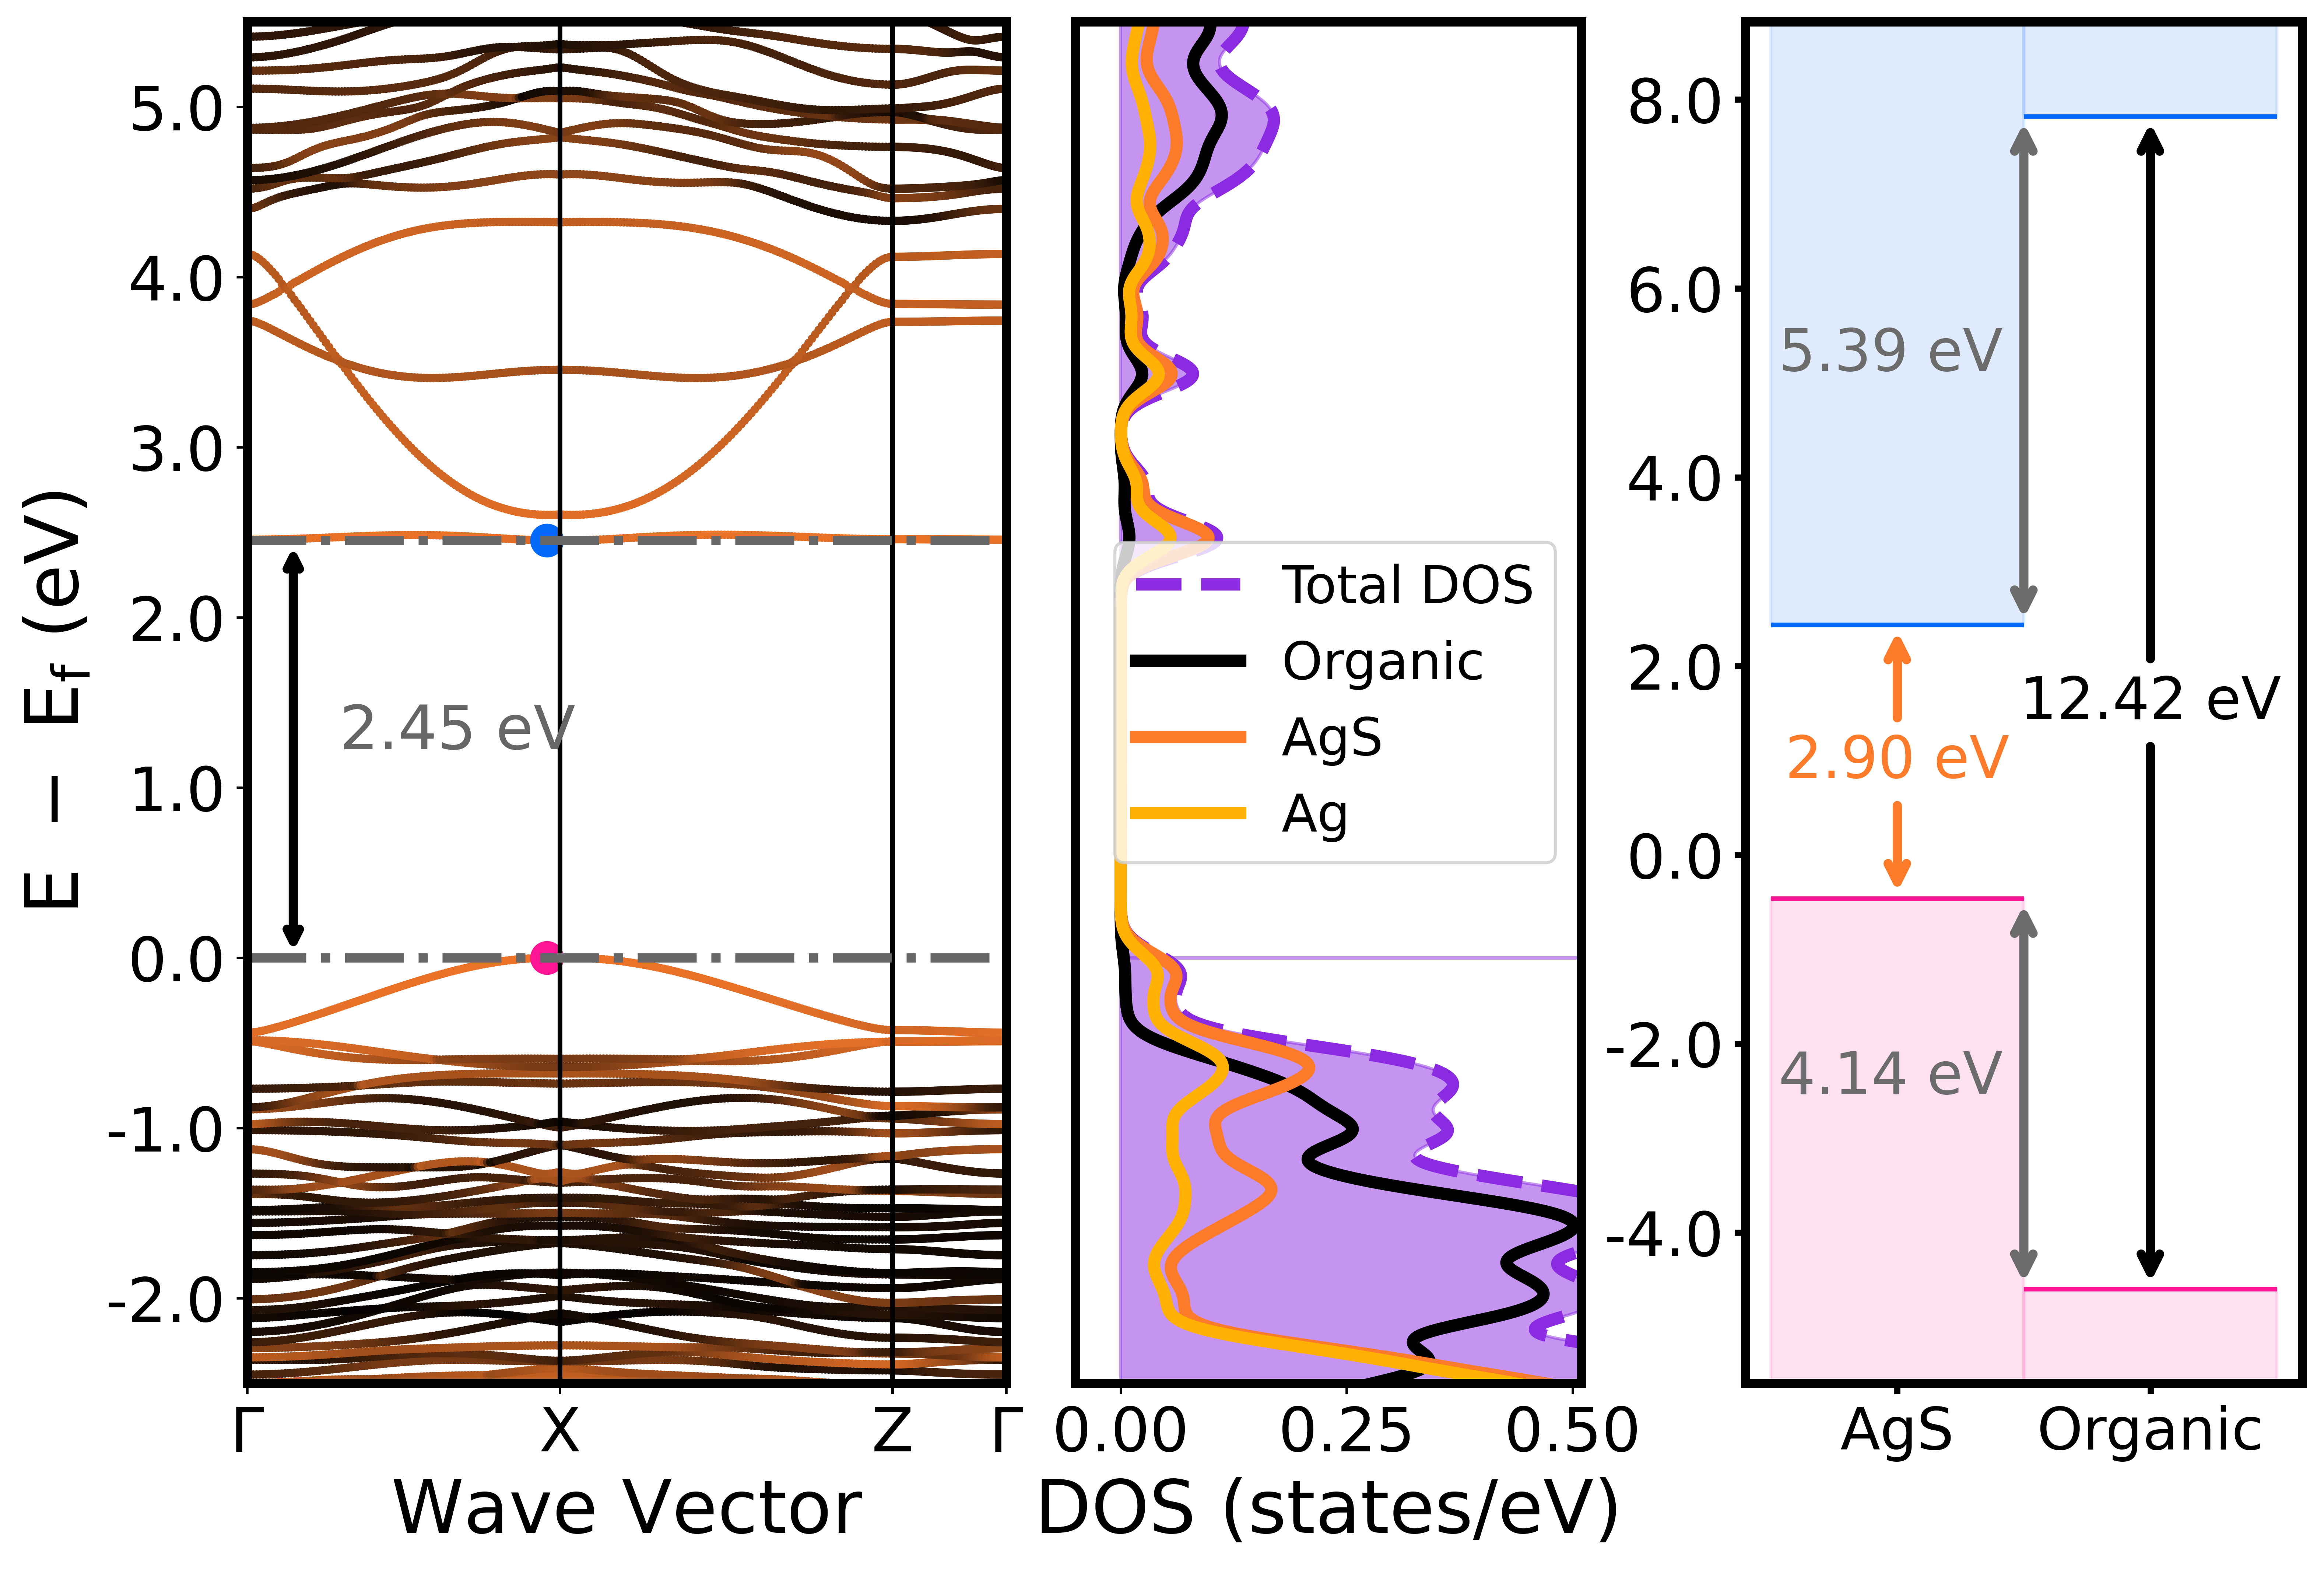

In [9]:
vbm, cbm = esp.color_bs_ba_plotter(bsp, aligner, dosplot, smooth=True, marker_size=3, energy_lim=[-2.5,5.5], dos_xlim=None, dos_xticks=None, band_xlim=[0,-1], vbm_marker=True, cbm_marker=True, legend=True)

## Get orbital contributions from band gap

In [ ]:
class deeznuts:
    def __init__(self, path, savefig):
        self.path = path
        self.savefig = savefig
    def sexy_orbital_plot(self, dos_list, norm=False, ylim=None, species=None, xlim=None, yticks=None):
        '''Get element DOS and plot according to whether
            the element is a metal, chalcogen, or organic.
            Axes are scaled automatically according to the range
            of energies and densities. '''
        path = self.path
        savefig = self.savefig
        zero_to_efermi = dos_list[0].zero_at_efermi 

        fuck = plt.figure(figsize=(8,3), dpi=600)
        gs = fuck.add_gridspec(1,2, wspace=0)
        ax = gs.subplots(sharey=True)
        
        max_list, min_list = [], []
        # dos_dict = dos.get
        for i, dos in enumerate(dos_list):
            # getting normalization shit
            for orb in dos.get_dos_dict():
                x = dos.get_dos_dict()[orb]['densities']['1']
                max_list.append(max(x))
                min_list.append(min(x))

        # max_val = max([max(dos.get_dos_dict()[orb]['densities']['1']) for dos in dos_list for orb in dos.get_])
        # min_val = min([min(x_plot[orb]) for orb in x_plot])

        ylims = []
        for i, dos in enumerate(dos_list):
            print(dos)
            cunt = 0
            colors = [ "#8A2BE2",'#0269fa', "#FF1493"]
            markers = ["o", "^", "."]
            lw = [3,2,1]

            dos_dict = dos.get_dos_dict()

            for orb in sorted(dos_dict):
                y = dos_dict[orb]['densities']['1']
                x =  dos_dict[orb]['energies']
                if norm and not (np.array(y) == 0).all():
                    norm_y = [(i - min(min_list)) / (max(max_list) - min(min_list)) for i in y]
                    print(min(norm_y), max(norm_y))
                    y = norm_y
                ylims.append(max(y))
                ax[i].plot(x, y, label=orb, c=colors[cunt], marker=markers[cunt], markersize=lw[cunt]+0.5,linewidth=lw[cunt])
                cunt += 1
            if norm:
                ax[0].set_ylabel(r"Normalized DOS (E/eV)")
            else:
                ax[0].set_ylabel(r"DOS (E/eV)")
            # ax[i].set_ylim(xlim[0], xlim[1])

            # ax[i].set_xlabel(r"Normalized DOS (E/eV)", fontsize=24)
            if ylim is None and yticks is None:
                ax[i].set_ylim(-0.1,max(ylim)+0.1)
                yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
                ax[i].set_yticks(yticks)
                ax[i].set_yticklabels(yticks, fontsize=20)
            elif yticks is None and ylim is not None:
                # ax[i].set_ylim(ylim[0], ylim[1])
                ax[i].set_ylim(ylim)
                ax[i].set_yticklabels([round(i, 2) for i in ax[i].get_yticks()])
            elif yticks is not None:
                ax[i].set_yticks(yticks)
                ax[i].set_yticklabels(yticks)
            if ylim is not None:
                ax[i].set_ylim(ylim)
                # ax[i].set_ylabel(r"Energies (eV)", fontsize=24)
            # els/e:
            #     ax[i].set_ylim(ylim[0], ylim[1])
            # ax[i].set_yticklabels(ax[i].get_yticks(), fontsize=20)

            # ax[i].set_yticks([0.0, 0.05, 0.1, 0.15, 0.2])
            # ylim_max = max(ylims)
            # print(ylim_max)
            # if ylim is None:
            #     ax[i].set_ylim(-1, ylim_max+1)
            #     print("yourmom")
            #     if norm:
            #         ax[i].set_ylim(-0.1,ylim_max+0.1)
            # else:
            #     ax[i].set_ylim(ylim)
            if xlim is not None:
                ax[i].set_xlim(xlim)
                print(xlim)
            else:
                pass
            ax[i].set_xlabel(r"Energies (eV)")
            ax[i].set_xticklabels([round(i, 2) for i in ax[i].get_xticks()])
            ax[i].legend(loc='upper right')
            
            for spine in ax[i].spines.values():
                spine.set_linewidth(2)

        fuck.tight_layout()

        if savefig:
            fuck.savefig(f"{path}/figures-and-data/orbital_pdos_inorganic.png", dpi=600)
    
   

es = deeznuts(root, savefig=True)

species_of_interest = ["Ag", "S"]

structure = Structure.from_file(f"{root}/{rel_type}/scf/POSCAR")
species, pdos_list = [],[]

# species = []

for atom in range(len(structure)):
    if str(structure[atom].species)[:-1] in species_of_interest and str(structure[atom].species)[:-1] not in species:
        species.append(str(structure[atom].species)[:-1])
# species
# orbital contribution
orbitals = {'s': OrbitalType.s, 'p': OrbitalType.p, 'd':OrbitalType.d}
result = Vasprun(f'{root}/{rel_type}/dos/vasprun.xml', parse_potcar_file=False)
complete_dos = result.complete_dos
orbital_pdos_list = []
for s in species:
    pdos = complete_dos.get_element_spd_dos(s)
    orbital_pdos = DosPlotter()
    for orbital in orbitals:
            orbital_pdos.add_dos(f'{s}({orbital})', pdos[orbitals[orbital]])
    orbital_pdos_list.append(orbital_pdos)

es.sexy_orbital_plot(orbital_pdos_list, xlim=[-1.5, 4.5], norm=True, ylim=[0, 0.3], species=s)
# es.sexy_orbital_plot(orbital_pdos_list, xlim=[float(yourmom["vbm"])-1.5-float(yourmom["eFermi"]), float(yourmom["cbm"]+1.5)-float(yourmom["eFermi"])], norm=True, ylim=[0, 0.3], species=s)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/adrianaladera/Desktop/MIT/research/VASP_calculations/fluorescent_1D/unrefined_relaxing/3meth_1D2D_paper///scf/POSCAR'

In [ ]:
import numpy as np
# dos_xlim = [-0.025, 0.4]
dos_xlim = None
ylim= [-2.5, 5.0]
# ylim=[-25,10]
# xticks=[round(i, 2) for i in np.arange(0, dos_xlim[1], 0.2)]
xticks=None
# xticks.insert(1, 0.0)
print(xticks)

ass = "01"
vbmm, cbmm = True, True
 
if ass == "11":
    vbmm, cbmm = True, True
elif ass == "01":
    vbmm, cbmm = False, True
elif ass == "10":
    vbmm, cbmm = True, False
elif ass == "00":
    vbmm, cbmm = False, False

METALS = ['Ag', 'Au', 'Hg', 'Cu']
CHALCS = ['Te', 'Se', "S"]
class MyAss:
    
    # METALS = ['Ag', 'Au', 'Hg', 'Cu']
    # CHALCS = ['Te', 'Se', "S"]
    def __init__(self, path, savefig=False):   
        self.savefig = savefig
        self.path = path
    
    def color_bs_dos_plotter(
    self,
    bandz,
    dos,
    band_xlim,
    zero_to_efermi=True,
    # selected_indices=None,
    ylim=None,
    dos_xlim=None,
    xticks=None,
    smooth=False,
    vbm_marker=True,
    cbm_marker=True,
    smooth_tol=0,
    smooth_k=3,
    smooth_np=100,
    bs_labels=None,
    marker_size=None
    ):
        """
        By Tess Smidt and Adriana Ladera. 
        Dos Plotter by Adriana Ladera.
        Get a matplotlib object for the bandstructures plot.
        Multiple bandstructure objs are plotted together if they have the
        same high symm path.
        Args:
            zero_to_efermi: Automatically subtract off the Fermi energy from
                the eigenvalues and plot (E-Ef).
            ylim: Specify the y-axis (energy) limits; by default None let
                the code choose. It is vbm-4 and cbm+4 if insulator
                efermi-10 and efermi+10 if metal
            smooth (bool or list(bools)): interpolates the bands by a spline cubic.
                A single bool values means to interpolate all the bandstructure objs.
                A list of bools allows to select the bandstructure obs to interpolate.
            smooth_tol (float) : tolerance for fitting spline to band data.
                Default is None such that no tolerance will be used.
            smooth_k (int): degree of splines 1<k<5
            smooth_np (int): number of interpolated points per each branch.
            bs_labels: labels for each band for the plot legend.
        """
        path = self.path
        savefig = self.savefig
        fuck, (a0, a1) = plt.subplots(1, 2, figsize=(12,8), dpi=600, gridspec_kw={'width_ratios': [5, 3]})
        vbm_line, cbm_line = None, None

        ############ Plotting the DOS ############
        color_list = ["#FF1493","#fc7b2b", "#FFB000", "#8A2BE2", "#0269fa", "#e0a7fc"]

        dos_dict = dos.get_dos_dict()

        x_plot, y_plot, colors = {}, {}, {}

        inorganics = list(set(dos_dict.keys()).intersection(set(METALS + CHALCS)))
        organics = list(set(dos_dict.keys()) - set(inorganics))

        for orb, data in dos_dict.items():
            x = data["densities"]["1"]
            y = data["energies"]

            # Total DOS
            if "Total DOS" not in x_plot:
                x_plot["Total DOS"] = np.array(x)
                y_plot["Total DOS"] = np.array(y)
                colors["Total DOS"] = color_list[3]
            else:
                x_plot["Total DOS"] += np.array(x)

            # Inorganics
            if orb in inorganics:
                if orb in METALS:
                    x_plot[orb] = x
                    y_plot[orb] = y
                    colors[orb] = color_list[0]
                key = " + ".join(inorganics)
                x_plot[key] = x_plot.get(key, 0) + np.array(x)
                y_plot[key] = y
                colors[key] = color_list[2]

            # Organics
            elif orb in organics:
                key = " + ".join(organics)
                x_plot[key] = x_plot.get(key, 0) + np.array(x)
                y_plot[key] = y
                colors[key] = color_list[1]

        max_val = max([max(x_plot[orb]) for orb in x_plot])
        min_val = min([min(x_plot[orb]) for orb in x_plot])

        # Plotting
        for orb in x_plot.keys():
            norm_x = [(i - min_val) / (max_val - min_val) for i in x_plot[orb]]
            print(max(norm_x), min(norm_x))
            # Normalize if requested
            if orb == "Total DOS":
                a1.fill_between(norm_x, y_plot[orb], color=colors[orb], alpha=0.5)
                a1.plot(norm_x, y_plot[orb],label=orb, c=colors[orb], linewidth=4, linestyle="--")
                
            else:
                a1.plot(norm_x, y_plot[orb], label=orb,c=colors[orb], linewidth=4)

        a1.set_xlabel(r"DOS (states/eV)", fontsize=24)
        # a1.set_ylabel(r"Energies (eV)", fontsize=24)

        if dos_xlim is None and xticks is None:
            a1.set_xlim(-0.1, 1.2)
            xticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
            # xticks = np.linspace(0, 1, 6)
            a1.set_xticks(xticks)
        elif dos_xlim is not None:
            a1.set_xlim(dos_xlim)
        if xticks is not None:
            a1.set_xticks(xticks)
            a1.set_xticklabels(xticks, fontsize=20)

        if ylim is not None:
            a1.set_ylim(ylim)
            yticks = a1.get_yticks()
            a1.set_yticklabels(yticks, fontsize=20)

        if not zero_to_efermi:
            # Example: get Fermi level from the first DOS entry
            efermi = next(iter(dos_dict.values()))["efermi"]
            a1.axhline(y=efermi, color="r", linestyle="--", label="$E_{Fermi}$", linewidth=1.5)

        # a1.grid(True)
        a1.legend(loc="upper right", fontsize=16)

es = MyAss(root, savefig=False)
# band_labels, vbm, cbm = es.color_bs_dos_plotter(bsp, dosplot, smooth=True, marker_size=3, ylim=ylim, dos_xlim=dos_xlim, xticks=xticks, band_xlim=[0,-1], vbm_marker=vbmm, cbm_marker=cbmm)
band_labels, vbm, cbm = esp.color_bs_dos_plotter(bsp, dosplot, smooth=True, marker_size=3, ylim=ylim, dos_xlim=dos_xlim, xticks=xticks, band_xlim=[0,-1], vbm_marker=vbmm, cbm_marker=cbmm)

None


AttributeError: 'ESP' object has no attribute 'color_bs_dos_plotter'

## Plot the corresponding Brillouin zone for the given band structure

In [ ]:
bsp.plot_brillouin() # the ugly Pymatgen version that's like 10 pixels
esp.sexier_brillouin_plot(bsp, band_labels, line_width, font_size)#,azim=45)

In [ ]:
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

bz_lattice = bsp._bs[0].lattice_rec
vertex1 = bz_lattice.get_cartesian_coords([0.0, 0.0, 0.0])
directions = [
        bz_lattice.get_cartesian_coords([1.0, 0.0, 0.0]) - vertex1,  # X-direction
        bz_lattice.get_cartesian_coords([0.0, 1.0, 0.0]) - vertex1,  # Y-direction
        bz_lattice.get_cartesian_coords([0.0, 0.0, 1.0]) - vertex1   # Z-direction
        ]

def plot_lattice_vectors(real_structure, elev=25, azim=35, lims=None, savefig=True):
    
    import matplotlib.pyplot as plt
    import pymatgen.electronic_structure.plotter as es
    import numpy as np

    fig = plt.figure(figsize=(8,8), dpi=600)
    ax = fig.add_subplot(111, projection='3d')

    real_lattice = real_structure.lattice.matrix
    spg_analy =SpacegroupAnalyzer(real_structure)
    prim_struct=spg_analy.get_primitive_standard_structure(international_monoclinic=False)
    prim_lattice = prim_struct.lattice.matrix
    recip_lattice = prim_struct.lattice.reciprocal_lattice.matrix

    for b in recip_lattice:
        queen = ax.quiver(*vertex1, *b, color='red', alpha=0.7, linewidth=3, arrow_length_ratio=0)
    for b in prim_lattice:
        queef = ax.quiver(*vertex1, *b, color='blue', alpha=0.7, linewidth=1, arrow_length_ratio=0)
        print(type(queef))

    if lims is None:
        lims = np.max(np.abs(np.concatenate(np.vstack([prim_lattice, real_lattice, recip_lattice])))) / 5
    # lims=7
    print(lims)

    # ax.quiverkey(queef, 1,1,1, "real space")
    ax.set_xlim(-lims, lims)
    ax.set_ylim(-lims, lims)
    ax.set_zlim(-lims, lims)

    ax.view_init(elev=elev, azim=azim)
#         ax.axis("off")

    plt.show()
    if savefig:
        fig.savefig(f"{root}/figures-and-data/lattice_vectors.png", dpi=600)

plot_lattice_vectors(Structure.from_file(f"{root}/scf/POSCAR"), savefig=True)
# esp.plot_lattice_vectors(Structure.from_file(f"{root}/scf/POSCAR"))


## Effective mass

In [ ]:
# root = "/Users/adrianaladera/Desktop/MIT/research/VASP_calculations/sugar_mochas/ligs_to_ISIF2/glu_v3"

# bandrun = BSVasprun(f"{root}/{rel_type}/band/vasprun.xml", parse_projected_eigen=True, occu_tol=1e-8)
# bs = bandrun.get_band_structure(f"{root}/{rel_type}/band/KPOINTS")
esp = ElectronicStructurePlotter(root, savefig=True)

yourmom = esp.get_band_data(bs)

data = inputs.DataVasp(f"{root}/band/OUTCAR", f"{root}/band/PROCAR")
settings = inputs.Settings(extrema_search_depth=0.2, energy_range=0.6)
vbm, cbm = float(yourmom["vbm"]), float(yourmom["cbm"])

effmass = EffectiveMass(root, data, settings)
segments = effmass.effmass_from_vbm_cbm(vbm-0.01, cbm+0.01, tol=1e-3)

## Get effmass data

In [ ]:
# effmass.get_effmass_data(segments, selected_indices=[i for i in range(10,20)]) #59
# effmass.get_effmass_data(segments, selected_indices=[6,52])
effmass.get_effmass_data(segments, selected_indices=[0,5])

## AgS MOCha Correlations

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Data
homo_lumo = np.array([
    4.115,
                       2.949, 3.861, 3.081, 3.773, 4.745, 4.653, 5.189, 5.207, 4.472, 4.945])
band_gap = np.array([
    1.546,
      1.735, 1.938, 1.780, 1.832, 2.175, 2.140, 2.832, 2.478, 2.453, 2.440])
# band_gap = np.array([
#     1.8233,
#     2.0664,
#     2.1050,
#     2.1414,
#     2.2339,
#     2.3088,
#     2.3217,
#     2.4454,
#     2.4454,
#     2.4454,
#     2.5670
# ]) # OPTICAL GAP

colors = [
    "#ff0000",
      "#ffbe00", "#ffe200", "#fcff00", "#b3ff00", "#77ff00", "#6cff00",
          "#00ff38", "#00ff38", "#00ff38", "#00e2ff"]
labels = [
    "2,6-dimethyl",
      "1-naphthyl", "3-OMe", "2-MMB", "2-OMe", "2-butane", "2-propane",
          "galactose", "glucose (dehyd)", "galactose (dehyd)", "glucose"]

# Compute Pearson correlation coefficient
r_value, _ = pearsonr(homo_lumo, band_gap)

# Marker shapes for the "#00ff38" entries
green_marker_shapes = ['s', '^', 'D']
green_index = 0

# Plot
plt.figure(figsize=(7, 5), dpi=600)
for x, y, color, label in zip(homo_lumo, band_gap, colors, labels):
    if color == "#00ff38":
        marker = green_marker_shapes[green_index]
        green_index += 1
    elif color == "#77ff00":
        marker = '*'
    elif color == "#6cff00":
        marker = 'h'
    else:
        marker = 'o'
    plt.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

# Remove duplicates in legend
handles, legend_labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
plt.legend(unique.values(), unique.keys(), title="Substituent", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show r-value on plot
plt.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Final plot formatting
plt.xlabel("HOMO-LUMO Gap (eV)")
plt.ylabel("Electronic Band Gap (eV)")
# plt.ylabel("Optical Gap (eV)")
plt.title("AgS MOChas")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Data
PL = np.array([1.8233, 2.0664, 2.1050, 2.1414, 2.3217, 2.5670])
homo_lumo = np.array([4.115, 2.949, 3.861, 3.081, 4.653, 4.945])
band_gap = np.array([1.546, 1.735, 1.938, 1.780, 2.140, 2.440])
inorganic_BG = np.array([1.695, 1.793, 2.096, 2.175, 2.001, 2.216])

# Set up subplots
fig, axs = plt.subplots(1,3, figsize=(12, 4), sharex=True, dpi=600)

# Helper function to plot with regression line
def plot_with_fit(ax, x, y, title, color):
    slope, intercept, r_value, _, _ = linregress(x, y)
    ax.scatter(x, y, color=color, label='Data')
    ax.plot(x, slope * x + intercept, color='black', linestyle='--', label=f'Fit (R²={r_value**2:.2f})')
    ax.set_ylabel(title)
    ax.legend()

# Plot each subplot
plot_with_fit(axs[0], PL, homo_lumo, 'HOMO-LUMO Gap', 'hotpink')
plot_with_fit(axs[1], PL, band_gap, 'Band Gap', 'dodgerblue')
plot_with_fit(axs[2], PL, inorganic_BG, 'Inorganic Band Gap', 'mediumseagreen')

# X-axis label
axs[0].set_xlabel('Optical Gap (eV)')
axs[1].set_xlabel('Optical Gap (eV)')
axs[2].set_xlabel('Optical Gap (eV)')

# Layout fix
plt.tight_layout()
plt.show()


## AuS Correlations

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Data
homo_lumo = np.array([
    3.681,
3.969,
4.210,
4.244])
# band_gap = np.array([
#     2.830,
# 2.945,
# 3.555,
# 3.203])
band_gap = np.array([
    1.7220,
1.8126,
1.8233,
1.9074
]) # OPTICAL GAP

colors = [
    "#db0000",
      "#ff0000", "#ff0000", "#ff0000"]
labels = [
    "AuS Ph-4F",
"AuS Ph",
"AuSe tPh (low T)",
"AuSe tPh (high T)"]

# Compute Pearson correlation coefficient
r_value, _ = pearsonr(homo_lumo, band_gap)

# Marker shapes for the "#00ff38" entries
green_marker_shapes = ['s', '^', 'D']
green_index = 0

# Plot
plt.figure(figsize=(7, 5), dpi=600)
for x, y, color, label in zip(homo_lumo, band_gap, colors, labels):
    if color == "#ff0000":
        marker = green_marker_shapes[green_index]
        green_index += 1
    # elif color == "#77ff00":
    #     marker = '*'
    # elif color == "#6cff00":
    #     marker = 'h'
    else:
        marker = 'o'
    plt.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

# Remove duplicates in legend
handles, legend_labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
plt.legend(unique.values(), unique.keys(), title="Substituent", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show r-value on plot
plt.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Final plot formatting
plt.xlabel("HOMO-LUMO Gap (eV)")
# plt.ylabel("Electronic Band Gap (eV)")
plt.ylabel("Optical Gap (eV)")
plt.title("AuS MOChas")
plt.grid(True)
plt.tight_layout()
plt.show()

## AgS and AuS MOChas

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Data
homo_lumo = np.array([3.681,
3.969,
4.210,
4.244,
    4.115,
                       2.949, 3.861, 3.081, 3.773, 4.745, 4.653, 5.189, 5.207, 4.472, 4.945])
# band_gap = np.array([2.830,
# 2.945,
# 3.555,
# 3.203,
#     1.546,
#       1.735, 1.938, 1.780, 1.832, 2.175, 2.140, 2.832, 2.478, 2.453, 2.440])
band_gap = np.array([
1.7220,
1.8126,
1.8233,
1.9074,
    1.8233,
    2.0664,
    2.1050,
    2.1414,
    2.2339,
    2.3088,
    2.3217,
    2.4454,
    2.4454,
    2.4454,
    2.5670
]) # OPTICAL GAP

colors = ["#db0000",
      "#ff0000", "#ff0000", "#ff0000",
    "#ff0000",
      "#ffbe00", "#ffe200", "#fcff00", "#b3ff00", "#77ff00", "#6cff00",
          "#00ff38", "#00ff38", "#00ff38", "#00e2ff"]
labels = ["AuS Ph-4F",
"AuS Ph",
"AuSe tPh (low T)",
"AuSe tPh (high T)",
    "2,6-dimethyl",
      "1-naphthyl", "3-OMe", "2-MMB", "2-OMe", "2-butane", "2-propane",
          "galactose", "glucose (dehyd)", "galactose (dehyd)", "glucose"]

# Compute Pearson correlation coefficient
r_value, _ = pearsonr(homo_lumo, band_gap)

# Marker shapes for the "#00ff38" entries
marker_shapes = ['s', '^', 'D', '*']
green_index, red_index = 0,0

# Plot
plt.figure(figsize=(7, 5), dpi=600)
for x, y, color, label in zip(homo_lumo, band_gap, colors, labels):
    if color == "#00ff38":
        marker = marker_shapes[green_index]
        green_index += 1
    elif color == "#ff0000":
        marker = marker_shapes[red_index]
        red_index += 1
    elif color == "#77ff00":
        marker = '*'
    elif color == "#6cff00":
        marker = 'h'
    else:
        marker = 'o'
    plt.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

# Remove duplicates in legend
handles, legend_labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
plt.legend(unique.values(), unique.keys(), title="Substituent", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show r-value on plot
plt.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Final plot formatting
plt.xlabel("HOMO-LUMO Gap (eV)")
# plt.ylabel("Electronic Band Gap (eV)")
plt.ylabel("Optical Gap (eV)")
plt.title("AgS and AuS MOChas")
plt.grid(True)
plt.tight_layout()
plt.show()

## Side by side subplot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

homo_lumo = np.array([
    4.115, 2.949, 3.861, 3.081, 3.773, 4.745, 4.653, 5.189, 5.207, 4.472, 4.945])

band_gap = np.array([
    1.546, 1.735, 1.938, 1.780, 1.832, 2.175, 2.140, 2.832, 2.478, 2.453, 2.440])

optical_gap = np.array([
    1.8233, 2.0664, 2.1050, 2.1414, 2.2339, 2.3088, 2.3217, 2.4454, 2.4454, 2.4454, 2.5670
]) 

colors = [
    "#ff0000", "#ffbe00", "#ffe200", "#fcff00", "#b3ff00", "#77ff00", "#6cff00",
    "#00ff38", "#00ff38", "#00ff38", "#00e2ff"]

labels = [
    "2,6-dimethyl", "1-naphthyl", "3-OMe", "2-MMB", "2-OMe", "2-butane", "2-propane",
    "galactose", "glucose (dehyd)", "galactose (dehyd)", "glucose"]

green_marker_shapes = ['s', '^', 'D']  # For #00ff38

fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=600)

def make_plot(ax, ydata, ylabel, title):
    r_value, _ = pearsonr(homo_lumo, ydata)
    green_index = 0
    count = 0
    for x, y, color, label in zip(homo_lumo, ydata, colors, labels):
        if color == "#00ff38":
            marker = green_marker_shapes[green_index]
            green_index += 1
        elif color == "#77ff00":
            marker = '*'
        elif color == "#6cff00":
            marker = 'h'
        else:
            marker = 'o'
        ax.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

    handles, legend_labels = ax.get_legend_handles_labels()
    unique = dict(zip(legend_labels, handles))
    ax.legend(unique.values(), unique.keys(), title="MOCha", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    ax.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

    ax.set_xlabel("HOMO-LUMO Gap (eV)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    count += 1

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

make_plot(axs[0], band_gap, "Electronic Band Gap (eV)", "AgS MOChas — Electronic")
make_plot(axs[1], optical_gap, "Optical Gap (eV)", "AgS MOChas — Optical")

plt.tight_layout()
plt.show()


## Red AgS and AuS MOChas

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Data
homo_lumo = np.array([
    3.681,
3.969,
4.210,
4.244,
4.115])
# band_gap = np.array([
#     2.830,
# 2.945,
# 3.555,
# 3.203,
# 1.546])
band_gap = np.array([
    1.7220,
1.8126,
1.8233,
1.9074,
1.8233
]) # OPTICAL GAP

colors = [
    "#db0000",
      "#ff0000", "#ff0000", "#ff0000", "#ff0000"]
labels = [
    "AuS Ph-4F",
"AuS Ph",
"AuSe tPh (low T)",
"AuSe tPh (high T)", "AgS 2,6-dimethyl"]

# Compute Pearson correlation coefficient
r_value, _ = pearsonr(homo_lumo, band_gap)

# Marker shapes for the "#00ff38" entries
green_marker_shapes = ['s', '^', 'D', '*']
green_index = 0

# Plot
plt.figure(figsize=(7, 5), dpi=600)
for x, y, color, label in zip(homo_lumo, band_gap, colors, labels):
    if color == "#ff0000":
        marker = green_marker_shapes[green_index]
        green_index += 1
    # elif color == "#77ff00":
    #     marker = '*'
    # elif color == "#6cff00":
    #     marker = 'h'
    else:
        marker = 'o'
    plt.scatter(x, y, color=color, edgecolor='black', s=100, marker=marker, label=label)

# Remove duplicates in legend
handles, legend_labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(legend_labels, handles))
plt.legend(unique.values(), unique.keys(), title="Substituent", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show r-value on plot
plt.text(0.05, 0.95, f"$r$ = {r_value:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"))

# Final plot formatting
plt.xlabel("HOMO-LUMO Gap (eV)")
plt.ylabel("Electronic Band Gap (eV)")
# plt.ylabel("Optical Gap (eV)")
plt.title("AuS and AgS red MOChas")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil

root = "/pscratch/sd/a/aladera/projects/fluorescent_1D/ligands"

for d in os.listdir(root):
    if os.path.exists(f"{root}/{d}/scf_band") and ("thiol" in d or "selenol" in d ):#or "tellurol" in d):
        if os.path.exists(f"{root}/{d}/scf_band/CONTCAR") and os.path.exists(f"{root}/{d}/scf_band/job.out") and not os.path.exists(f"{root}/{d}/band/CHG"):
            with open(f"{root}/{d}/scf_band/job.out") as f:
                lines = f.read()
                # if "reached required accuracy" in lines:
                if "1 F= " in lines:
                    print(f"{d} is done!")
                # else:
                    print(f"DONE, can resubmit {d}!")
                    os.system(f"cp {root}/{d}/scf_band/CHG* {root}/{d}/band")
                    os.chdir(f"{root}/{d}/band/")
                    print(os.getcwd())
                    os.system("sbatch run.slurm")
                    os.chdir(root)
                    print(os.getcwd())
    # else:
#        print("your mom")

In [ ]:
pazz = "/Users/adrianaladera/Desktop/MIT/RESEARCH/VASP_calculations/3-positions/"
import numpy as np
from pymatgen.io.vasp import Kpoints

for mocha in ["4methoxy", "3hydroxy", "3amino", "3methoxy"]:
    for dirr in os.listdir(f"{pazz}/{mocha}"):
        kp_orig = Kpoints.from_file(f"{pazz}/{mocha}/band/KPOINTS")
        for i,j in zip(kp_orig.labels, kp_orig.kpts):
            if "band_" in dirr:
                for file in os.listdir(f"{pazz}/{mocha}/{dirr}"):
                    if "KPOINTS" in file:
                        print(mocha, dirr, "KPOINTS")
                        # print(file, mocha)
                        kp = Kpoints.from_file(f"{pazz}/{mocha}/{dirr}/{file}")
                        for l, k in zip(kp.labels, kp.kpts):
                            if np.array_equal(j, k) and i != l:
                                print(i, l, k)
            elif os.path.exists(f"{pazz}/{mocha}/band/KPOINTS_test"):
                kp = Kpoints.from_file(f"{pazz}/{mocha}/band/KPOINTS_test")
                print(mocha, "band", "KPOINTS_test")
                for a, b in zip(kp.labels, kp.kpts):
                    if np.array_equal(j, b) and i != a:
                        print(i, a, b)

    # os.path.exists(f"{pazz}/{mocha}/band") or


In [ ]:
ass = np.array([0, 0 ,1])
dookie = np.array([0,0,0])

if np.array_equal(ass, dookie):
    print("YOUR MOM")

In [ ]:
ass = "jhelo"
bitch = "hello"
if ass != bitch:
    print("THEY MATCH")